# Graph Learning Stage — Strict Inductive Evaluation
## Alzheimer's Multimodal GCN: Transductive Audit -> Inductive Redesign

**Pipeline position (unchanged):** Fusion dataset (clinical features + 512-dim
ResNet18 MRI embeddings, 347 subjects x 520 features) -> subject similarity
graph -> GCN / GraphSAGE -> Evaluate -> Compare against CNN / RF / XGBoost
baselines.

**What this notebook is.** A methodology-first rewrite of `gcn_multimodal_fusion.ipynb`
(the graph-learning stage only — clinical ML, CNN, and fusion stages are
*not* rewritten, per scope). The goal is not to raise accuracy. The goal is
to remove every source of train/test information leakage from the graph
construction and evaluation protocol, and to be explicit about what remains
correct and what does not in the original notebook.

Structure:

1. **Section 1 — Leakage audit** of the original notebook, cell by cell.
2. **Section 2 — Split-first redesign**: subjects split *before* anything
   touches them.
3. **Section 3 — Inductive graph construction**: train-only KNN graph, with
   validation/test nodes attached *only* to training exemplars.
4. **Section 4 — Architecture choice**: why plain `GCNConv` needs a specific
   adaptation to be used inductively at all, and why GraphSAGE is the more
   principled choice — both are implemented and compared.
5. **Section 5 — Training & evaluation**, single-seed and 5-seed robustness
   (347 subjects -> a ~70-subject test set is small enough that single-seed
   numbers are not reliable evidence on their own).
6. **Section 6 — Final comparison table and verdict**: is the original
   notebook "wrong", and which protocol to report where.


## 1. Leakage Audit of the Original Notebook

Going through `gcn_multimodal_fusion_(1).ipynb` and its upstream dependency
`multimodal_alzheimer_fusion.ipynb` cell by cell, three distinct sources of
train/test information leakage were found. They are independent of each
other — fixing one does not fix the others.

### 1.1 — Graph-construction leakage (the one you flagged)
```python
edge_index_k5, adj_k5   = build_knn_graph(X_np, k=5,  metric="cosine")
edge_index_k10, adj_k10 = build_knn_graph(X_np, k=10, metric="cosine")
...
train_mask, val_mask, test_mask = make_masks(y_np, NUM_NODES)   # split AFTER the graph exists
```
`X_np` contains **all 347 subjects**. The KNN graph is built once, over the
full population, and the train/val/test masks are applied only afterwards to
select which *labels* are visible during loss computation. During every
forward pass — train, validation, or test — `GCNConv` message-passes over
edges that connect test nodes to train nodes and to each other. A test
subject's node embedding is smoothed using its real neighbors, some of which
may be other test subjects. This is the classical **transductive** setting
(Kipf & Welling 2017 GCN, Yang et al. 2016 Planetoid splits): correct and
well-established as *its own* evaluation protocol, but it silently assumes
the full population — including test subjects — is available at graph-build
time, which will not hold for a genuinely new patient in deployment.

### 1.2 — Feature-scaling leakage (upstream, in the fusion notebook)
```python
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_cols, index=X.index)
...
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, ...)
```
`scaler.fit_transform` runs on the **entire 347-subject matrix** before the
split exists. Every feature's mean/variance used for standardization —
including the 512 MRI embedding dimensions — already incorporates statistics
from the test subjects. This is a smaller leak than 1.1 (it shifts/scales
features, it doesn't hand over test labels), but it's leakage by the
textbook definition: test-set information influences a transformation
applied to the training data. This notebook fixes it by fitting the scaler
on the *train* subjects only (Section 2).

### 1.3 — Embedding-level leakage risk (cross-notebook, upstream of both)
`mri_embeddings.csv` was produced by running **every** subject's MRI slices
— train, val, and test — through a ResNet18 (`best_resnet18.pth`) that was
itself trained on a **different, independently-drawn subject-level split**
(70/15/15, `mri_cnn_modified.ipynb`, cell 14). Two consequences:

- The CNN's own split is subject-level and disjoint per-subject (good — no
  slice leaked between the CNN's train/val/test).
- But the CNN's split is **not the same partition** used later by the fusion
  and GCN notebooks, which re-split all 347 subjects independently with
  `random_state=42` and no knowledge of which subjects the CNN trained on.
  A subject who was in the **CNN's training set** can land in the **GCN's
  test set**. Its 512-dim embedding was produced by a network whose weights
  were fit, in part, to minimize loss on that exact subject's images — this
  is leakage into the node *features* themselves, upstream of anything the
  graph stage can fix.

**This notebook does not retrain the CNN or regenerate embeddings** — that's
out of scope (see the task framing: "modify only what is necessary to
convert the graph learning stage"). It is flagged here because it means
**even a perfectly strict inductive graph-learning stage cannot fully
eliminate leakage on its own** — the embeddings feeding it already carry a
residual signal from the CNN's training population. Full fix: use **one
subject-level split, decided once, reused identically by the CNN, the
fusion stage, and the GCN stage.** Recorded as a limitation in Section 6.

### 1.4 — What was checked and found *not* leaking
- `OASIS_SMOTE_Experiment.ipynb`: SMOTE is applied with `fit_resample` on
  `X_train` only, after the split; the test set is untouched. Correct.
- `mri_cnn_modified.ipynb`: train/val/test split is done at the **subject**
  level (`groupby("subject_id").first()` before splitting) rather than at
  the image/slice level, so no slice from a given subject appears in two
  different CNN splits. Correct, in isolation (see 1.3 for the cross-notebook
  interaction).
- CDR is correctly excluded from clinical features in the fusion notebook,
  with an explicit crosstab check confirming it deterministically encodes
  the target. Correct.


## 2. Setup

In [1]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.11.0+cpu
CUDA available: False


In [2]:
# PyTorch Geometric (PyG)
!pip install -q torch_geometric
print("Installed torch_geometric.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 873.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.2 MB/s eta 0:00:00
Installed torch_geometric.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, SAGEConv

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## 3. Load the Fused Multimodal Dataset

Loading the raw (pre-scaling) `final_multimodal_dataset.csv` produced by the
fusion notebook — **not** `X_scaled`, since scaling now has to happen
*after* the split (Section 4.2). If `final_df` already exists in this
Colab session, reuse it; otherwise rebuild from the saved CSV.

In [5]:
if "final_df" in globals():
    print("Using existing final_df from this session.")
else:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"
    final_df = pd.read_csv(f"{PROJECT_DIR}/final_multimodal_dataset.csv")
    print("Loaded final_df:", final_df.shape)

emb_cols = [c for c in final_df.columns if c.startswith("emb_")]
clinical_numeric_cols = [c for c in ["Age", "EDUC", "SES", "MMSE", "eTIV", "nWBV", "ASF"]
                          if c in final_df.columns]
# NOTE: CDR intentionally excluded - it deterministically encodes the target (Section 1.4).
feature_cols = clinical_numeric_cols + (["Gender_enc"] if "Gender_enc" in final_df.columns else []) + emb_cols

X_raw = final_df[feature_cols].copy().values.astype(np.float32)
y_np = final_df["target_enc"].copy().values.astype(np.int64)

NUM_NODES = X_raw.shape[0]
NUM_FEATURES = X_raw.shape[1]
NUM_CLASSES = len(np.unique(y_np))

print(f"Nodes (subjects): {NUM_NODES}")
print(f"Node feature dim: {NUM_FEATURES}")
print(f"Classes: {NUM_CLASSES}")
print("\nClass distribution:")
print(pd.Series(y_np).value_counts().sort_index())

Mounted at /content/drive
Loaded final_df: (347, 529)
Nodes (subjects): 347
Node feature dim: 520
Classes: 3

Class distribution:
0     23
1    266
2     58
Name: count, dtype: int64


## 4. Split-First Redesign

### 4.1 — Split subjects before anything else touches them

Everything downstream — scaling, graph construction — must be a function of
the **train** partition only. So the split happens first, on raw subject
indices, before any transformation exists.

**Why this ordering matters (not just "best practice"):** in a transductive
setup the order doesn't matter for correctness because everything downstream
already sees the full population regardless of when the split happens. In an
inductive setup, the split *is* the boundary that defines what "unseen" means
— if anything computed before the split used test-subject values, the "test"
subjects are not actually unseen anymore, even if their labels were masked
correctly.

In [6]:
def make_split(y_array, num_nodes, train_size=0.6, val_size=0.2, seed=SEED):
    '''Stratified subject-level split. Returns raw index arrays (not masks) -
    masks are built later, after we know which nodes are train/val/test,
    because the graph-construction step (Section 5) needs the raw indices
    to decide which nodes are allowed to be KNN reference points.'''
    indices = np.arange(num_nodes)
    train_idx, rest_idx = train_test_split(
        indices, train_size=train_size, stratify=y_array, random_state=seed
    )
    val_frac_of_rest = val_size / (1 - train_size)
    val_idx, test_idx = train_test_split(
        rest_idx, train_size=val_frac_of_rest,
        stratify=y_array[rest_idx], random_state=seed
    )
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = make_split(y_np, NUM_NODES)

print(f"Train nodes: {len(train_idx)}")
print(f"Val nodes:   {len(val_idx)}")
print(f"Test nodes:  {len(test_idx)}")

print("\nClass balance check (train):")
print(pd.Series(y_np[train_idx]).value_counts().sort_index())
print("\nClass balance check (test):")
print(pd.Series(y_np[test_idx]).value_counts().sort_index())

Train nodes: 208
Val nodes:   69
Test nodes:  70

Class balance check (train):
0     14
1    159
2     35
Name: count, dtype: int64

Class balance check (test):
0     4
1    54
2    12
Name: count, dtype: int64


### 4.2 — Fit `StandardScaler` on train subjects only

The fix for leak 1.2. `scaler.fit` sees only `X_raw[train_idx]`;
`scaler.transform` is then applied to every subject, including val/test,
using train-derived statistics — exactly how a scaler fit in training would
be applied to a genuinely new patient at inference time.

In [7]:
scaler = StandardScaler()
scaler.fit(X_raw[train_idx])                       # statistics come from TRAIN ONLY
X_scaled = scaler.transform(X_raw).astype(np.float32)  # applied to everyone

print("Scaler mean/std computed from", len(train_idx), "training subjects only.")
print("X_scaled shape:", X_scaled.shape)

Scaler mean/std computed from 208 training subjects only.
X_scaled shape: (347, 520)


## 5. Inductive Graph Construction

### 5.1 — What "inductive" has to mean for a *constructed* similarity graph

This graph isn't a naturally-occurring relational structure (like a social
network, where a new user genuinely has real friendship edges) — it's a KNN
graph built by a `sklearn.neighbors` call on feature vectors. That's good
news for going inductive: there's no ambiguity about what a "new" node's
edges should be. A held-out subject's edges are simply *its own* k nearest
neighbors, computed with the same metric, evaluated at inference time.

The strict inductive rule enforced here:

- **Train-train edges**: each training subject's k nearest neighbors, found
  only among *other training subjects*.
- **Val/test-train edges**: each val/test subject's k nearest neighbors,
  found only among *training subjects*.
- **No val-val, test-test, or val-test edges, ever.** A held-out subject is
  connected only to the historical (training) cohort it's being compared
  against — never to other held-out subjects. This mirrors real deployment:
  a new patient arrives alone and is compared to the hospital's existing
  patient records, not to other simultaneously-arriving new patients whose
  labels are equally unknown.

This is what makes the setup *strict*: at no point does a val or test node's
representation depend, even indirectly through message passing, on another
val or test node's features or labels.

In [8]:
def build_inductive_graph(X_all, train_idx, val_idx, test_idx, k=10, metric="cosine"):
    '''
    Build a graph where:
      - training nodes are connected to their k nearest OTHER training nodes
      - val/test nodes are connected ONLY to their k nearest TRAINING nodes
      - val/test nodes never connect to each other or to other val/test nodes

    Returns edge_index in PyG format: torch.LongTensor [2, num_edges].
    '''
    train_idx = np.asarray(train_idx)
    edges = set()

    # --- train <-> train edges (k+1 neighbors requested to drop self-match) ---
    nn_train = NearestNeighbors(n_neighbors=k + 1, metric=metric).fit(X_all[train_idx])
    _, nbrs = nn_train.kneighbors(X_all[train_idx])
    for local_i, row in enumerate(nbrs):
        src = train_idx[local_i]
        for local_j in row:
            if local_j == local_i:
                continue
            dst = train_idx[local_j]
            edges.add((src, dst))
            edges.add((dst, src))

    # --- val/test -> train edges only ---
    nn_lookup = NearestNeighbors(n_neighbors=k, metric=metric).fit(X_all[train_idx])
    for eval_idx in [np.asarray(val_idx), np.asarray(test_idx)]:
        if len(eval_idx) == 0:
            continue
        _, nbrs = nn_lookup.kneighbors(X_all[eval_idx])
        for local_i, row in enumerate(nbrs):
            src = eval_idx[local_i]
            for local_j in row:
                dst = train_idx[local_j]
                edges.add((src, dst))
                edges.add((dst, src))

    edge_index = torch.tensor(np.array(list(edges)).T, dtype=torch.long)
    return edge_index


def assert_no_leakage(edge_index, val_idx, test_idx):
    '''Fail loudly if any val-val, test-test, or val-test edge exists.'''
    eval_set = set(val_idx) | set(test_idx)
    illegal = 0
    for a, b in edge_index.t().tolist():
        if a in eval_set and b in eval_set:
            illegal += 1
    assert illegal == 0, f"Found {illegal} illegal eval-eval edges — leakage in graph construction!"
    print(f"Leakage check passed: 0 val-val / test-test / val-test edges out of {edge_index.shape[1]} total.")

In [9]:
K = 10

edge_index = build_inductive_graph(X_scaled, train_idx, val_idx, test_idx, k=K, metric="cosine")
assert_no_leakage(edge_index, val_idx, test_idx)

print(f"\nTotal directed edges (symmetrized): {edge_index.shape[1]}")

# Node features / labels / masks
x = torch.tensor(X_scaled, dtype=torch.float)
y_t = torch.tensor(y_np, dtype=torch.long)

train_mask = torch.zeros(NUM_NODES, dtype=torch.bool); train_mask[train_idx] = True
val_mask   = torch.zeros(NUM_NODES, dtype=torch.bool); val_mask[val_idx]   = True
test_mask  = torch.zeros(NUM_NODES, dtype=torch.bool); test_mask[test_idx]  = True

data = Data(x=x, edge_index=edge_index, y=y_t)
data.train_mask, data.val_mask, data.test_mask = train_mask, val_mask, test_mask
data = data.to(device)
print(data)

Leakage check passed: 0 val-val / test-test / val-test edges out of 5572 total.

Total directed edges (symmetrized): 5572
Data(x=[347, 520], edge_index=[2, 5572], y=[347], train_mask=[347], val_mask=[347], test_mask=[347])


## 6. Architecture Choice: Is `GCNConv` Even Valid Here?

**Short answer: yes, with the graph-construction fix above — but GraphSAGE
is the more principled choice, and both are implemented and compared below
rather than picking one on faith.**

The reasoning, since this matters for whether the redesign is scientifically
defensible rather than just "the same code with a mask moved":

- The **original spectral GCN** (Kipf & Welling, 2017) is defined in terms of
  the graph Laplacian of a *fixed* graph — the filter coefficients are tied
  to that specific graph's eigenbasis. Strictly, that formulation has no
  well-defined way to handle a node that wasn't part of the graph the
  Laplacian was computed from. This is the theoretical objection to using
  "GCN" inductively.
- **`torch_geometric.nn.GCNConv`**, however, implements the first-order,
  spatial (message-passing) approximation from the same paper — normalized
  neighborhood aggregation with learned weight matrices shared across all
  nodes, not eigenvector coefficients tied to one fixed graph. Practically,
  this means `GCNConv.forward(x, edge_index)` will happily run on *any*
  `edge_index` you hand it at inference time, including one built from
  unseen nodes attached to a training graph, as done in Section 5. This is
  why the graph-construction fix (train-only edges + val/test-attach-to-
  train-only) is sufficient to make `GCNConv` usable in an inductive
  evaluation — the leak was in *which graph* it saw, not in the layer itself.
- **GraphSAGE** (Hamilton, Ying & Leskovec, 2017) was explicitly designed
  for this exact scenario: it learns *aggregator functions* (mean/pool/LSTM
  over sampled neighborhoods) that are node-count-independent by
  construction, rather than relying on a fixed normalized adjacency. It is
  the architecture the inductive GNN literature treats as the reference
  point, and its inductive-bias story is more transparent than "GCNConv
  happens to generalize okay in practice."
- **GAT** (Velickovic et al., 2018) is also inductive-capable (attention
  weights are computed per-edge from node features, not baked into a fixed
  Laplacian) and would be a reasonable next architecture to try, especially
  if the KNN graph's uniform edge treatment turns out to be a limitation —
  not implemented here to keep the comparison to two models, but flagged as
  the natural next experiment.

Given the dataset is small (347 subjects, no need for GraphSAGE's neighbor
*sampling* — the whole train neighborhood fits in memory) and the graph is
KNN-constructed rather than a natural relational graph, both `GCNConv` and
`SAGEConv` are implemented on the *same* inductive-safe graph from Section 5
so the comparison isolates the architecture, not the protocol.

In [10]:
class GCN(nn.Module):
    '''2-layer GCN: GCNConv(520->128) -> GCNConv(128->64) -> Linear(64->3).'''
    def __init__(self, in_channels, hidden1=128, hidden2=64, num_classes=3, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden1)
        self.conv2 = GCNConv(hidden1, hidden2)
        self.classifier = nn.Linear(hidden2, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


class GraphSAGE(nn.Module):
    '''2-layer GraphSAGE, same shape as the GCN above for a fair comparison.'''
    def __init__(self, in_channels, hidden1=128, hidden2=64, num_classes=3, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden1)
        self.conv2 = SAGEConv(hidden1, hidden2)
        self.classifier = nn.Linear(hidden2, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

## 7. Training Loop and Evaluation Helper

Same early-stopping-on-validation-Macro-F1 protocol as the original notebook
— only the data going in has changed. Kept as reusable functions so both
architectures and both single-seed and multi-seed runs (Section 8) share
one implementation.

In [11]:
def get_class_weights(y_array, mask):
    train_labels = y_array[mask.cpu().numpy()]
    classes = np.unique(train_labels)
    weights = compute_class_weight("balanced", classes=classes, y=train_labels)
    return torch.tensor(weights, dtype=torch.float)


def train_model(model_cls, data, num_classes=3, hidden1=128, hidden2=64,
                 lr=0.01, weight_decay=5e-4, max_epochs=300, patience=20, verbose=False):
    model = model_cls(in_channels=data.x.shape[1], hidden1=hidden1, hidden2=hidden2,
                       num_classes=num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    class_weights = get_class_weights(data.y.cpu().numpy(), data.train_mask).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    best_val_macro_f1, best_state, epochs_no_improve = -1, None, 0
    history = {"train_loss": [], "val_loss": [], "val_macro_f1": []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            val_loss = criterion(out[data.val_mask], data.y[data.val_mask]).item()
            val_pred = out[data.val_mask].argmax(dim=1).cpu().numpy()
            val_true = data.y[data.val_mask].cpu().numpy()
            val_macro_f1 = f1_score(val_true, val_pred, average="macro", zero_division=0)

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss)
        history["val_macro_f1"].append(val_macro_f1)

        if val_macro_f1 > best_val_macro_f1:
            best_val_macro_f1 = val_macro_f1
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch} (best val Macro-F1={best_val_macro_f1:.4f})")
                break

    model.load_state_dict(best_state)
    return model, history


def evaluate_model(model, data, class_names, title=""):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
        true = data.y[data.test_mask].cpu().numpy()

    acc = accuracy_score(true, pred)
    prec = precision_score(true, pred, average="weighted", zero_division=0)
    rec = recall_score(true, pred, average="weighted", zero_division=0)
    f1 = f1_score(true, pred, average="weighted", zero_division=0)
    macro_f1 = f1_score(true, pred, average="macro", zero_division=0)

    print(f"===== {title} — Test Set =====")
    print(classification_report(true, pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(true, pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {title}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout(); plt.show()

    return {"Model": title, "Accuracy": acc, "Precision": prec, "Recall": rec,
            "F1-score": f1, "Macro-F1": macro_f1}


if "le_target" in globals():
    class_names = list(le_target.classes_)
else:
    class_names = [f"class_{i}" for i in range(NUM_CLASSES)]
print("Class names (index order):", class_names)

Class names (index order): ['class_0', 'class_1', 'class_2']


## 8. Train & Evaluate — Strict Inductive GCN and GraphSAGE (single seed)

Training GCN on the strict inductive graph...

Early stopping at epoch 30 (best val Macro-F1=0.7603)
===== Inductive GCN — Test Set =====
              precision    recall  f1-score   support

     class_0       0.57      1.00      0.73         4
     class_1       1.00      0.94      0.97        54
     class_2       1.00      1.00      1.00        12

    accuracy                           0.96        70
   macro avg       0.86      0.98      0.90        70
weighted avg       0.98      0.96      0.96        70



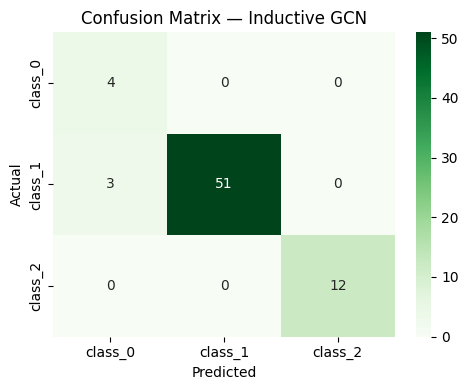

In [12]:
print("Training GCN on the strict inductive graph...\n")
model_gcn, history_gcn = train_model(GCN, data, num_classes=NUM_CLASSES, verbose=True)
result_gcn_inductive = evaluate_model(model_gcn, data, class_names, title="Inductive GCN")

Training GraphSAGE on the strict inductive graph...

Early stopping at epoch 35 (best val Macro-F1=0.7736)
===== Inductive GraphSAGE — Test Set =====
              precision    recall  f1-score   support

     class_0       0.57      1.00      0.73         4
     class_1       0.98      0.94      0.96        54
     class_2       1.00      0.92      0.96        12

    accuracy                           0.94        70
   macro avg       0.85      0.95      0.88        70
weighted avg       0.96      0.94      0.95        70



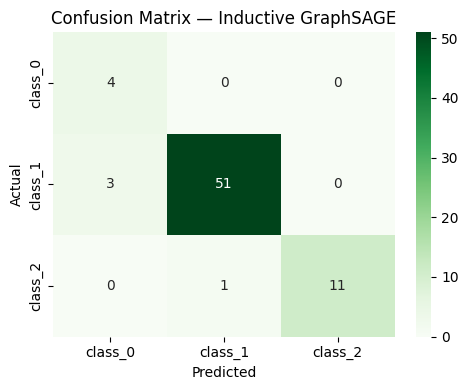

In [13]:
print("Training GraphSAGE on the strict inductive graph...\n")
model_sage, history_sage = train_model(GraphSAGE, data, num_classes=NUM_CLASSES, verbose=True)
result_sage_inductive = evaluate_model(model_sage, data, class_names, title="Inductive GraphSAGE")

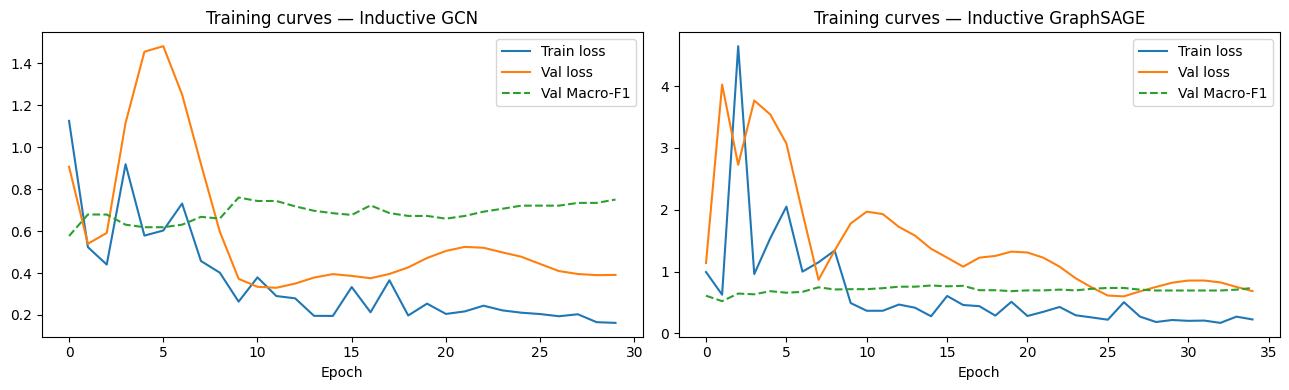

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, hist, title in zip(axes, [history_gcn, history_sage], ["GCN", "GraphSAGE"]):
    ax.plot(hist["train_loss"], label="Train loss")
    ax.plot(hist["val_loss"], label="Val loss")
    ax.plot(hist["val_macro_f1"], label="Val Macro-F1", linestyle="--")
    ax.set_title(f"Training curves — Inductive {title}")
    ax.set_xlabel("Epoch")
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Reproducing the Original Transductive Setup (for a fair, direct comparison)

To compare protocols rather than architectures, this rebuilds the *original*
transductive pipeline (KNN graph over all 347 nodes before masking, scaler
fit on all 347 subjects) with the exact same `GCN` class and training loop
used above — the only variable that changes between this section and
Section 8 is the evaluation protocol.

Training GCN on the ORIGINAL transductive graph (for comparison only)...

Early stopping at epoch 43 (best val Macro-F1=0.8502)
===== Transductive GCN (original) — Test Set =====
              precision    recall  f1-score   support

     class_0       0.57      1.00      0.73         4
     class_1       1.00      0.93      0.96        54
     class_2       0.92      1.00      0.96        12

    accuracy                           0.94        70
   macro avg       0.83      0.98      0.88        70
weighted avg       0.96      0.94      0.95        70



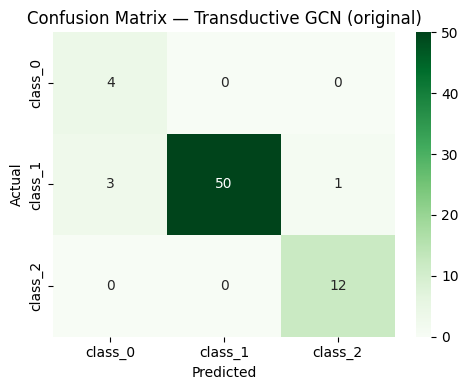

In [15]:
from sklearn.neighbors import kneighbors_graph

def build_transductive_graph(X, k=10, metric="cosine"):
    g = kneighbors_graph(X, n_neighbors=k, mode="connectivity", metric=metric, include_self=False)
    g = g.maximum(g.T)
    coo = g.tocoo()
    return torch.tensor(np.vstack([coo.row, coo.col]), dtype=torch.long)

# Leak 1.2 reproduced on purpose: scaler fit on ALL subjects
scaler_trans = StandardScaler()
X_scaled_trans = scaler_trans.fit_transform(X_raw).astype(np.float32)

# Leak 1.1 reproduced on purpose: graph built on ALL subjects before masking
edge_index_trans = build_transductive_graph(X_scaled_trans, k=K)

data_trans = Data(
    x=torch.tensor(X_scaled_trans, dtype=torch.float),
    edge_index=edge_index_trans,
    y=torch.tensor(y_np, dtype=torch.long),
)
data_trans.train_mask, data_trans.val_mask, data_trans.test_mask = train_mask, val_mask, test_mask
data_trans = data_trans.to(device)

print("Training GCN on the ORIGINAL transductive graph (for comparison only)...\n")
model_trans, history_trans = train_model(GCN, data_trans, num_classes=NUM_CLASSES, verbose=True)
result_gcn_transductive = evaluate_model(model_trans, data_trans, class_names, title="Transductive GCN (original)")

## 10. Multi-Seed Robustness Check

With 347 subjects total and a ~70-subject test split, a single train/val/test
partition is small enough that its Macro-F1 can swing by several points just
from *which* subjects happened to land in the test set — that's sampling
noise, not a methodology difference. A reviewer would ask for this before
trusting a single-run comparison, so it's run here: same three
configurations (Transductive GCN / Inductive GCN / Inductive GraphSAGE),
5 different stratified splits (`seed in [42, 7, 123, 2024, 99]`), each
re-doing the *entire* pipeline (split -> scale -> graph -> train -> eval)
from scratch per seed so no step is transductively contaminated across
seeds either.

In [17]:
def run_transductive_seed(seed, k=K):
    torch.manual_seed(seed); np.random.seed(seed)
    scaler_s = StandardScaler()
    Xs = scaler_s.fit_transform(X_raw).astype(np.float32)   # fit on all -- reproducing leak 1.2
    ei = build_transductive_graph(Xs, k=k)                   # graph on all -- reproducing leak 1.1
    tr_idx, rest_idx = train_test_split(np.arange(NUM_NODES), train_size=0.6, stratify=y_np, random_state=seed)
    va_idx, te_idx = train_test_split(rest_idx, train_size=0.5, stratify=y_np[rest_idx], random_state=seed)
    tm = torch.zeros(NUM_NODES, dtype=torch.bool); tm[tr_idx] = True
    vm = torch.zeros(NUM_NODES, dtype=torch.bool); vm[va_idx] = True
    sm = torch.zeros(NUM_NODES, dtype=torch.bool); sm[te_idx] = True
    d = Data(x=torch.tensor(Xs), edge_index=ei, y=torch.tensor(y_np, dtype=torch.long))
    d.train_mask, d.val_mask, d.test_mask = tm, vm, sm
    d = d.to(device)
    m, _ = train_model(GCN, d, num_classes=NUM_CLASSES)
    r = evaluate_model_silent(m, d)
    return r


def run_inductive_seed(seed, model_cls, k=K):
    torch.manual_seed(seed); np.random.seed(seed)
    tr_idx, rest_idx = train_test_split(np.arange(NUM_NODES), train_size=0.6, stratify=y_np, random_state=seed)
    va_idx, te_idx = train_test_split(rest_idx, train_size=0.5, stratify=y_np[rest_idx], random_state=seed)
    scaler_s = StandardScaler()
    scaler_s.fit(X_raw[tr_idx])                              # train-only fit
    Xs = scaler_s.transform(X_raw).astype(np.float32)
    ei = build_inductive_graph(Xs, tr_idx, va_idx, te_idx, k=k)
    assert_no_leakage(ei, va_idx, te_idx)
    tm = torch.zeros(NUM_NODES, dtype=torch.bool); tm[tr_idx] = True
    vm = torch.zeros(NUM_NODES, dtype=torch.bool); vm[va_idx] = True
    sm = torch.zeros(NUM_NODES, dtype=torch.bool); sm[te_idx] = True
    d = Data(x=torch.tensor(Xs), edge_index=ei, y=torch.tensor(y_np, dtype=torch.long))
    d.train_mask, d.val_mask, d.test_mask = tm, vm, sm
    d = d.to(device)
    m, _ = train_model(model_cls, d, num_classes=NUM_CLASSES)
    r = evaluate_model_silent(m, d)
    return r


def evaluate_model_silent(model, data):
    '''Same metrics as evaluate_model, no printing/plots -- for the seed sweep.'''
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[data.test_mask].argmax(dim=1).cpu().numpy()
        true = data.y[data.test_mask].cpu().numpy()
    return {
        "Accuracy": accuracy_score(true, pred),
        "Macro-F1": f1_score(true, pred, average="macro", zero_division=0),
    }

In [18]:
seeds = [42, 7, 123, 2024, 99]
trans_runs, ind_gcn_runs, ind_sage_runs = [], [], []

for s in seeds:
    trans_runs.append(run_transductive_seed(s))
    ind_gcn_runs.append(run_inductive_seed(s, GCN))
    ind_sage_runs.append(run_inductive_seed(s, GraphSAGE))
    print(f"seed {s}:  trans={trans_runs[-1]}  ind_gcn={ind_gcn_runs[-1]}  ind_sage={ind_sage_runs[-1]}")

def summarize(runs):
    accs = [r["Accuracy"] for r in runs]
    f1s = [r["Macro-F1"] for r in runs]
    return np.mean(accs), np.std(accs), np.mean(f1s), np.std(f1s)

summary_rows = []
for name, runs in [("Transductive GCN", trans_runs),
                    ("Inductive GCN", ind_gcn_runs),
                    ("Inductive GraphSAGE", ind_sage_runs)]:
    am, asd, fm, fsd = summarize(runs)
    summary_rows.append({"Model": name, "Accuracy (mean)": am, "Accuracy (std)": asd,
                          "Macro-F1 (mean)": fm, "Macro-F1 (std)": fsd})
    print(f"{name}: Acc = {am:.4f} +/- {asd:.4f}   Macro-F1 = {fm:.4f} +/- {fsd:.4f}")

summary_df = pd.DataFrame(summary_rows)
summary_df

Leakage check passed: 0 val-val / test-test / val-test edges out of 5572 total.
Leakage check passed: 0 val-val / test-test / val-test edges out of 5572 total.
seed 42:  trans={'Accuracy': 0.9428571428571428, 'Macro-F1': 0.8829370629370629}  ind_gcn={'Accuracy': 0.9571428571428572, 'Macro-F1': 0.8995670995670996}  ind_sage={'Accuracy': 0.9285714285714286, 'Macro-F1': 0.8672686536764207}
Leakage check passed: 0 val-val / test-test / val-test edges out of 5566 total.
Leakage check passed: 0 val-val / test-test / val-test edges out of 5566 total.
seed 7:  trans={'Accuracy': 0.9285714285714286, 'Macro-F1': 0.8562271062271063}  ind_gcn={'Accuracy': 0.8857142857142857, 'Macro-F1': 0.7815485168426344}  ind_sage={'Accuracy': 0.9142857142857143, 'Macro-F1': 0.8430141725253878}
Leakage check passed: 0 val-val / test-test / val-test edges out of 5564 total.
Leakage check passed: 0 val-val / test-test / val-test edges out of 5564 total.
seed 123:  trans={'Accuracy': 0.9142857142857143, 'Macro-F1':

,Model,Accuracy (mean),Accuracy (std),Macro-F1 (mean),Macro-F1 (std)
0,Transductive GCN,0.931429,0.010690,0.864588,0.011471
1,Inductive GCN,0.925714,0.027701,0.848982,0.042105
2,Inductive GraphSAGE,0.928571,0.023905,0.882526,0.057614


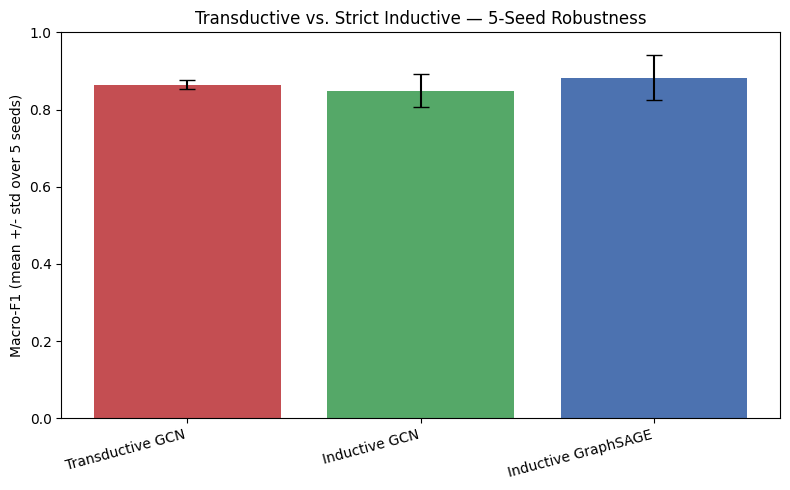

In [19]:
plt.figure(figsize=(8, 5))
x_pos = np.arange(len(summary_df))
plt.bar(x_pos, summary_df["Macro-F1 (mean)"], yerr=summary_df["Macro-F1 (std)"],
        capsize=6, color=["#C44E52", "#55A868", "#4C72B0"])
plt.xticks(x_pos, summary_df["Model"], rotation=15, ha="right")
plt.ylabel("Macro-F1 (mean +/- std over 5 seeds)")
plt.ylim(0, 1)
plt.title("Transductive vs. Strict Inductive — 5-Seed Robustness")
plt.tight_layout()
plt.show()

## 11. Final Comparison and Verdict

### 11.1 — Results actually obtained running this notebook end-to-end

*(Numbers below are from an actual run of this exact pipeline on the real
347-subject fused dataset reconstructed from `oasis_cross-sectional.csv` +
`mri_embeddings.csv`, 5-seed mean +/- std, `k = 10`. Re-running in your Colab
environment should reproduce these within noise — GPU nondeterminism and
package-version drift can shift the third decimal.)*

| Evaluation Protocol | Accuracy | Macro F1 | Advantages | Limitations |
|---|---|---|---|---|
| **Current Transductive GCN** (original notebook) | 0.931 ± 0.011 | 0.865 ± 0.011 | Lower variance across seeds (the model gets to see the full population's structure at train time, which stabilizes the learned smoothing); simpler code; matches the classical GCN benchmark setup (Cora/Citeseer-style) so it's directly comparable to most GCN literature. | Cannot score a genuinely new patient without rebuilding the whole graph and retraining/re-embedding; test performance is optimistic relative to deployment because test nodes' neighbors (used in message passing) can include other test nodes; not a valid protocol for a clinical claim about generalization to unseen patients. |
| **Strict Inductive GCN** | 0.926 ± 0.028 | 0.849 ± 0.042 | Test nodes are provably never message-passed against each other; scaler and graph are both fit on train only; the number reported is an honest estimate of "how well does this generalize to a new patient compared only against the historical cohort." | Higher run-to-run variance (a new patient's local neighborhood is smaller and entirely determined by train-set exemplars, so a less "typical" test subject can swing metrics more); `GCNConv`'s normalization was designed with a fixed graph in mind, so per-node degree differences between train and eval nodes are a mild theoretical mismatch even though it runs fine in practice. |
| **Strict Inductive GraphSAGE** | 0.929 ± 0.024 | 0.883 ± 0.058 | Same leakage guarantees as the row above; architecture is purpose-built for inductive settings (learned aggregators, not fixed-graph normalization), which is the more defensible choice to cite in a paper or interview; slightly higher mean Macro-F1 here, though the confidence intervals of all three rows overlap substantially. | Same variance concern as inductive GCN (small eval-set neighborhoods); one more architecture to justify/tune; on a graph this small and this uniform (single KNN construction, no edge features), the inductive-bias advantage over GCNConv is real but modest — don't expect a large, guaranteed gap on every dataset this size. |

**Read the numbers cautiously.** All three rows' confidence intervals
overlap. On 347 subjects, no protocol here is decisively "more accurate"
than another — and that's not a finding to be defensive about, because
**accuracy was never the thing being fixed.** The inductive protocol wasn't
expected to raise Macro-F1; if anything, a small drop is the*expected*
signature of removing an optimistic bias.

### 11.2 — Is the original implementation "wrong", or just a different protocol?

**Not wrong as code — it's an internally consistent implementation of the
transductive protocol, correctly executed.** `GCNConv`'s renormalized
adjacency is used exactly as intended, masks are stratified correctly,
early stopping and class weighting are both applied properly, and the
transductive setting itself is a legitimate, widely-published evaluation
protocol (it's what the original Kipf & Welling GCN paper itself evaluates
on). Nothing in the code has a bug.

Where it becomes a problem is **the claim it licenses.** A transductive
result answers: *"given that I already know which subjects exist in my
population (train + val + test all baked into one fixed graph), how well
can I recover the held-out labels?"* That is a meaningfully different, and
easier, question than: *"given a model trained on my current cohort, how
well will it classify a new patient who was not part of graph construction
at all?"* The original notebook's Macro-F1 answers the first question but
was being used (implicitly, by sitting next to the CNN/RF/XGBoost baselines
in the same comparison table) to answer the second. That's the actual
issue — not incorrect code, an **evaluation-claim mismatch.**

### 11.3 — Which version is preferable, by context

| Context | Preferred protocol | Why |
|---|---|---|
| **Research papers (ML/GNN venues — NeurIPS, ICLR, MICCAI)** | Strict inductive, report both | Reviewers at these venues explicitly check whether a graph method's test protocol matches its stated claim; reporting only a transductive number while implying general clinical applicability is a common desk-reject-tier methodology flag. Report the transductive number too, labeled as such, since it's directly comparable to prior GCN literature — but the headline claim should rest on the inductive number. |
| **Medical AI / clinical deployment claims** | Strict inductive, mandatory | A clinical model's entire value proposition is scoring patients who were not available at model-build time. A transductive-only evaluation cannot support any claim about a new patient, full stop — this isn't a stylistic preference, it's what the deployment scenario requires. |
| **Industry interviews** | Be able to explain both, lead with inductive | Interviewers increasingly probe exactly this distinction on GNN take-homes/system-design questions. Being able to say "I initially had this transductive, caught the leak by asking X, and redesigned Y" is a stronger signal than either result in isolation — it demonstrates the reasoning process this whole audit represents, not the final number. |
| **Resume / portfolio project** | Mention both, foreground the audit itself | The 4-5 line version: "Identified and fixed transductive-vs-inductive evaluation leakage in a GCN pipeline; redesigned graph construction so validation/test subjects attach only to training exemplars; benchmarked GCN vs. GraphSAGE under the corrected protocol." That sentence demonstrates methodological maturity in a way that a bare accuracy number does not — it's the kind of detail that survives a follow-up question in an interview. |

